In [1]:
from generate_data import *
from types import SimpleNamespace
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'generate_data'

In [2]:
# Specify the configuration
args =  SimpleNamespace(
        dataset='cifar10',
        timesteps=1000,
        device='cuda',
        batch_size=8, 
        guidance_scale=2.0,
        ddim=True,
        sampling_steps=50,
        pretrained_ckpt='/n/fs/wy-project/minimal-diffusion/trained_models3/UNet_cifar10-epoch_500-timesteps_1000-class_condn_True_ema_0.9995.pt',
        arch='UNet',
        diffusion_steps=1000,
    )

In [3]:
# setup diffusion model
metadata = get_metadata(args.dataset)
model = unets.__dict__[args.arch](
    image_size=metadata.image_size,
    in_channels=metadata.num_channels,
    out_channels=metadata.num_channels,
    num_classes=metadata.num_classes,
).to(args.device)
diffusion = GaussianDiffusion(args.diffusion_steps, args.device)

In [4]:
# load the pre-trained model
print(f"Loading pretrained model from {args.pretrained_ckpt}")
d = fix_legacy_dict(torch.load(args.pretrained_ckpt, map_location=args.device))
dm = model.state_dict()
model.load_state_dict(d, strict=False)

Loading pretrained model from /n/fs/wy-project/minimal-diffusion/trained_models3/UNet_cifar10-epoch_500-timesteps_1000-class_condn_True_ema_0.9995.pt


/tmp/ipykernel_1269257/3593399949.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = fix_legacy_dict(torch.load(args.pretrained_ckpt, map_location=args.device))


<All keys matched successfully>

In [5]:
# Sample from the diffusion model
model.eval()
sampled_images, labels, conditional_gradients, inputs_list = sample_N_images(
    0,
    8,
    model,
    diffusion,
    args.sampling_steps,
    args.batch_size,
    metadata.num_channels,
    metadata.image_size,
    metadata.num_classes,
    args,
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.13s/it]

Sampling progress: 8/8 images (0 to 7)


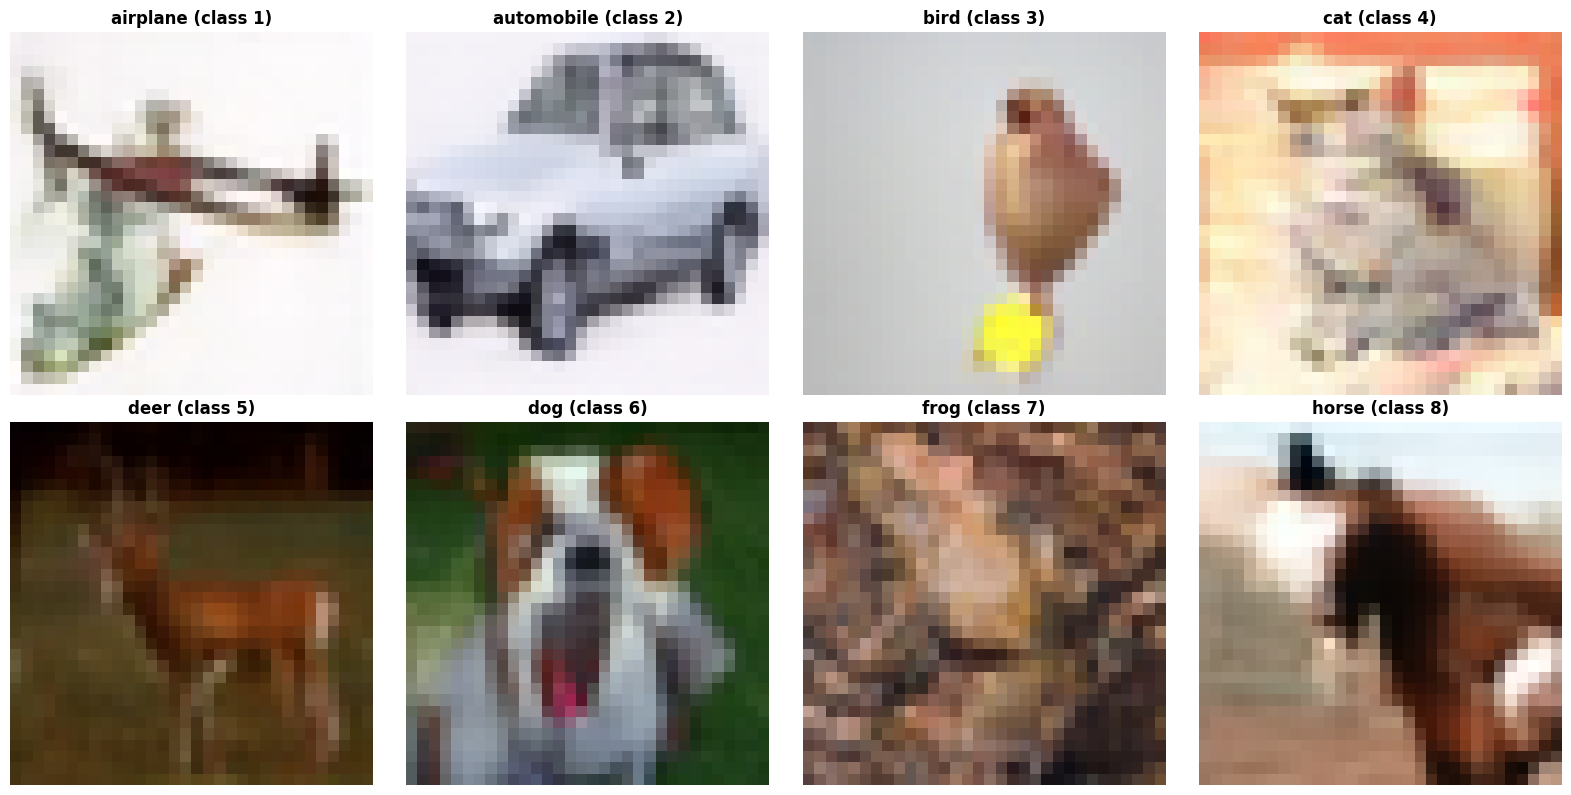

In [6]:
# Visualize the generated images
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
# Create a 2x4 grid to display the 8 images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    # Display the image
    axes[i].imshow(sampled_images[i])
    axes[i].axis('off')
    # Set title with class name (labels are 1-indexed, so subtract 1 for 0-indexed class_names)
    class_idx = labels[i] - 1
    title = f"{class_names[class_idx]} (class {labels[i]})"
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()

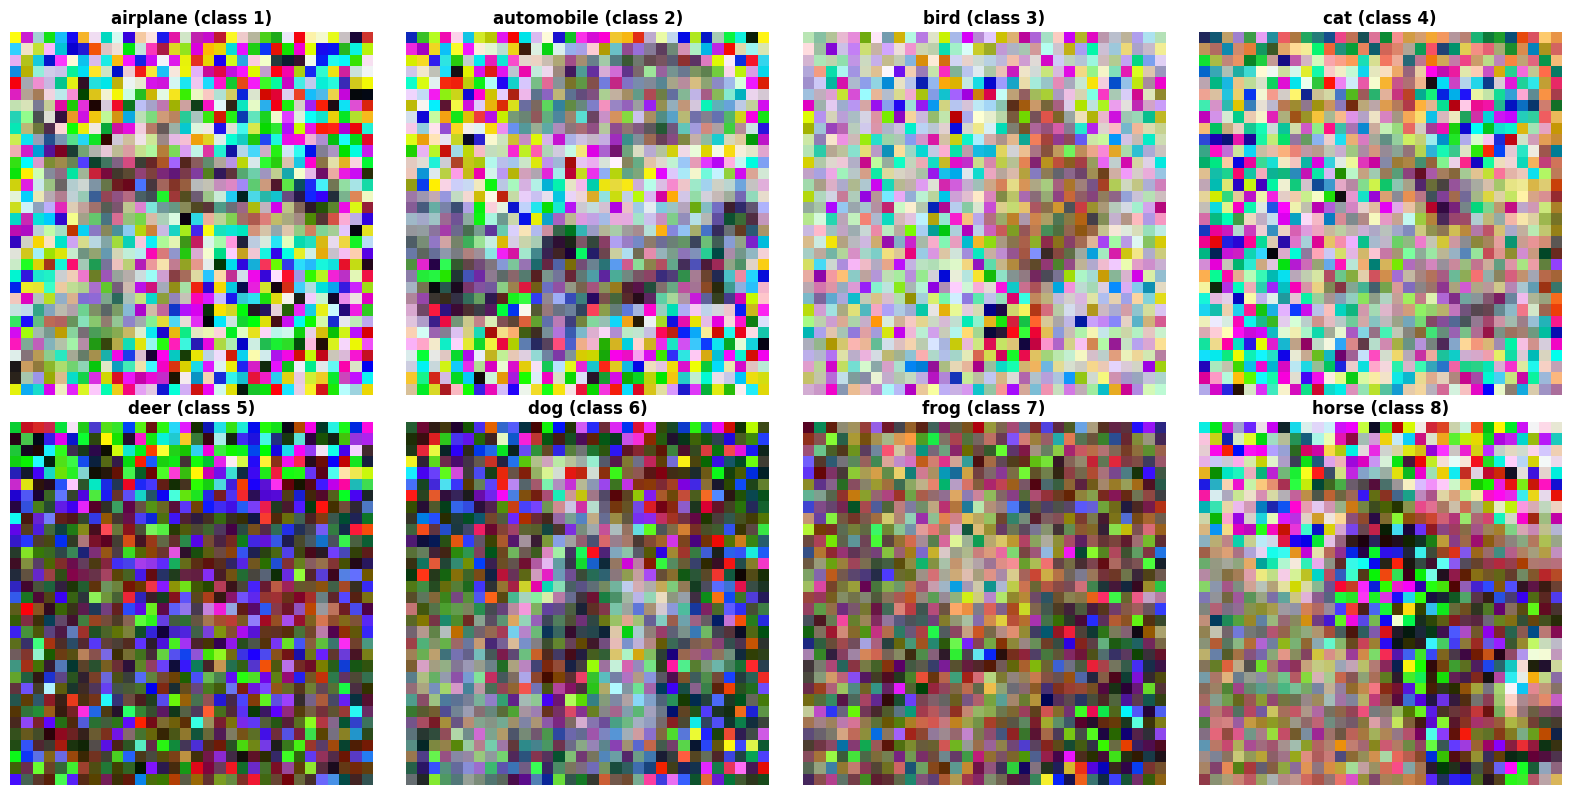

In [ ]:
# visualize the intermediate generated images
t = 40 # which timestep to visualize? (0 is the initial image, 49 is the penultimate image)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    # Display the image
    axes[i].imshow((127.5 * (inputs_list[i][t].transpose(1, 2, 0) + 1)).astype(np.uint8))
    axes[i].axis('off')
    class_idx = labels[i] - 1
    title = f"{class_names[class_idx]} (class {labels[i]})"
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5179283..0.39378253].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2318802..0.34213513].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32430506..0.3403199].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.51497..0.59778816].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.37991306..0.24950737].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23224124..0.4100548].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3

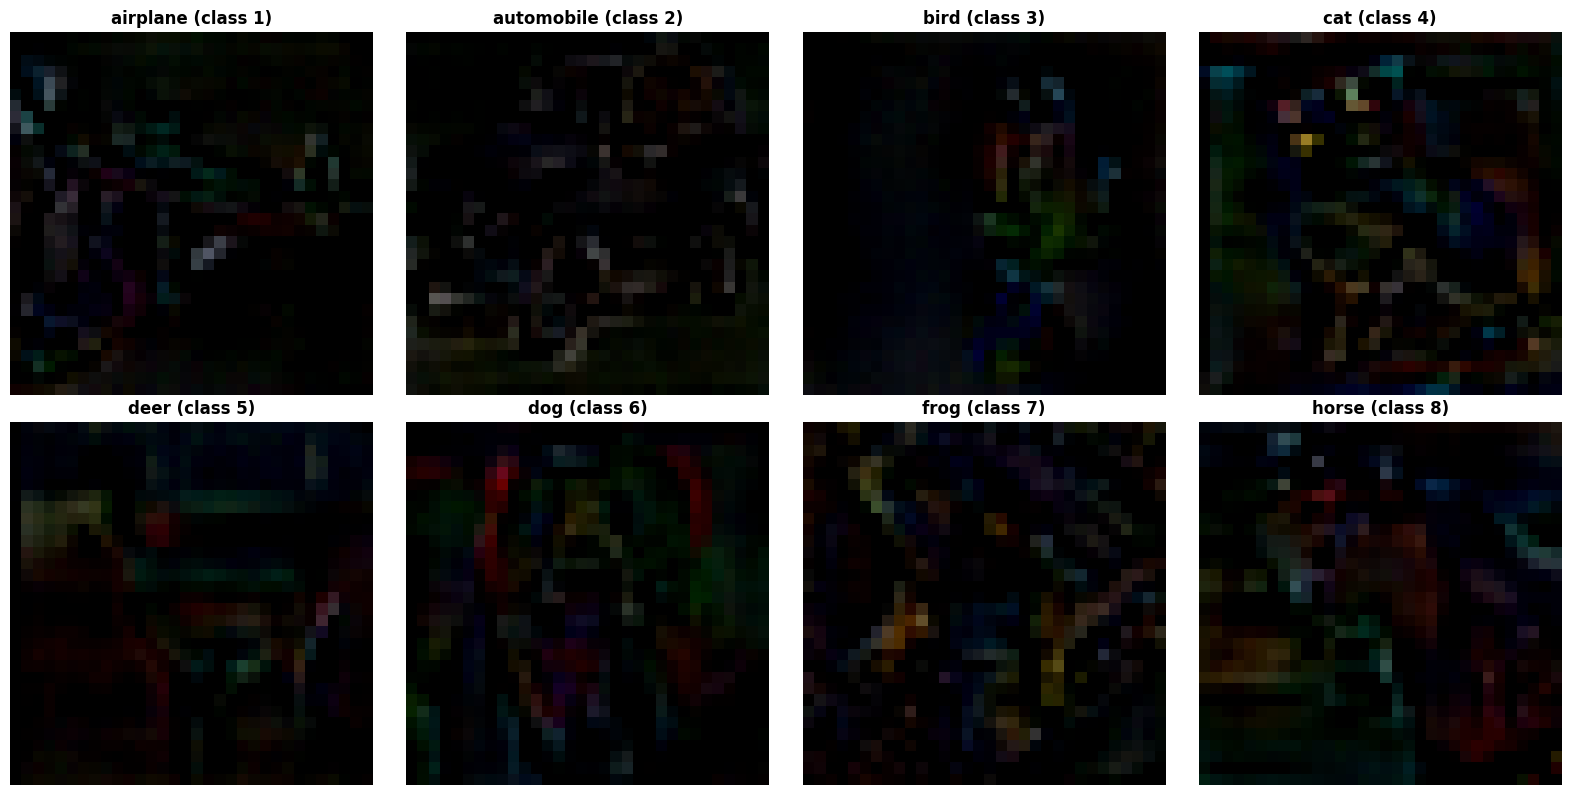

In [11]:
# visualize the gradients produced at different timesteps
t = 40
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(conditional_gradients[i][t].transpose(1, 2, 0))
    axes[i].axis('off')
    class_idx = labels[i] - 1
    title = f"{class_names[class_idx]} (class {labels[i]})"
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()

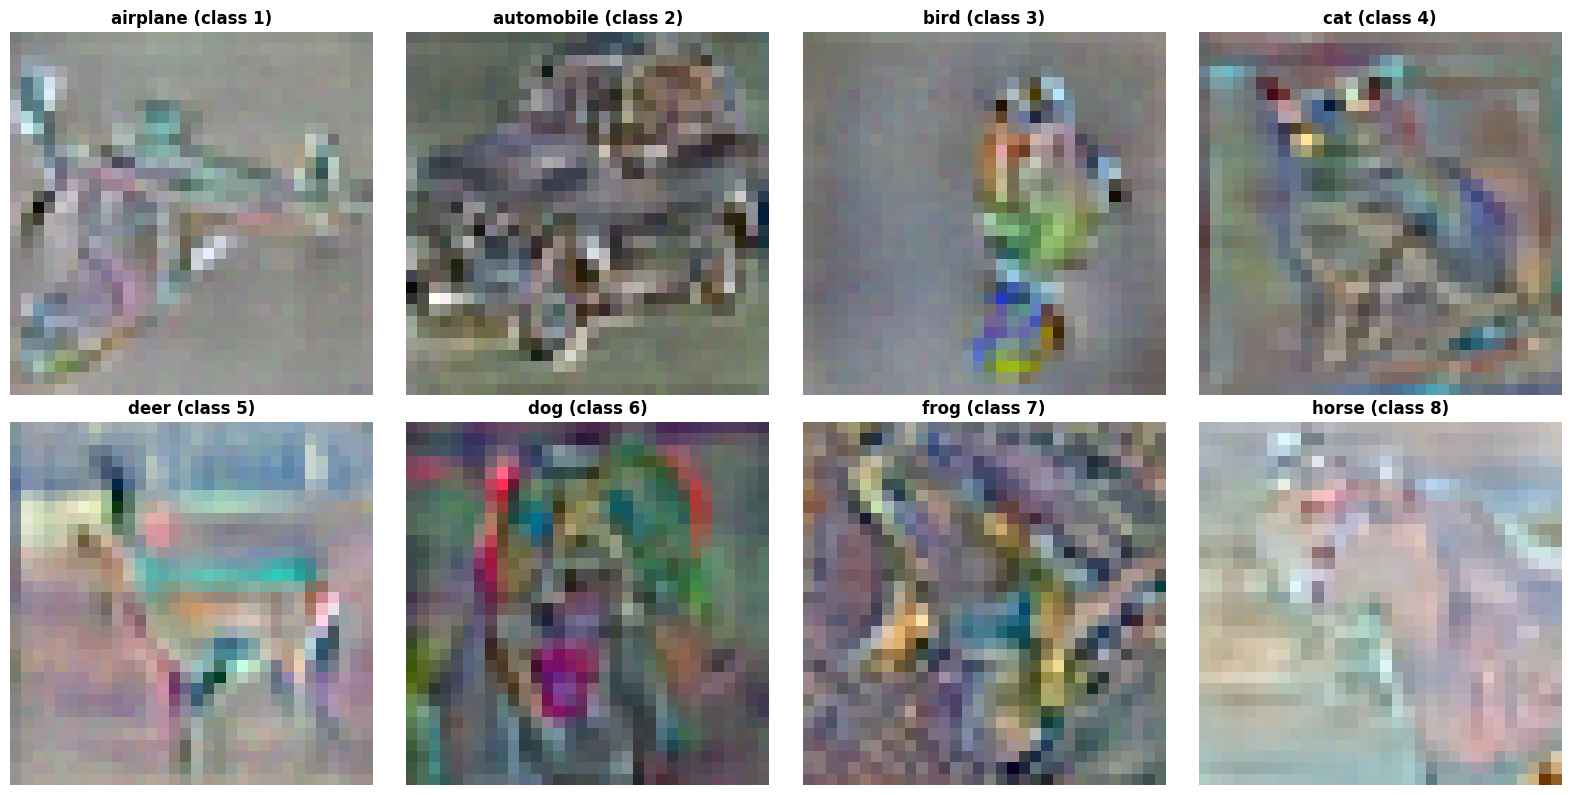

In [12]:
# normalize the gradients to 0 and 1 for better visualization
t = 40
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    gradients = conditional_gradients[i][t].transpose(1, 2, 0)
    normalized_gradients = (gradients - gradients.min()) / (gradients.max() - gradients.min())
    axes[i].imshow(normalized_gradients)
    axes[i].axis('off')
    class_idx = labels[i] - 1
    title = f"{class_names[class_idx]} (class {labels[i]})"
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()